# 北上广深租房市场数据分析

## 第七部分：整租面积、卧室数量与月租金关系分析

In [1]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/rent_cleaned.csv")

df = pd.read_csv(DATA_PATH)

print("数据规模：", df.shape)

数据规模： (11978, 26)


## 一、建立整租分析数据

In [2]:
# 建立整租分析数据
entire_df = df[
    df["type"] == "整租"
].copy()

print("清洗数据数量：", len(df))
print("整租房源数量：", len(entire_df))
print("出租类型：", entire_df["type"].unique())

清洗数据数量： 11978
整租房源数量： 11564
出租类型： <StringArray>
['整租']
Length: 1, dtype: str


## 二、检查异常标记记录

In [3]:
# 统计三类异常标记的整租记录数量
small_entire_count = entire_df[
    "is_small_entire"
].sum()

large_area_conflict_count = entire_df[
    "is_large_area_conflict"
].sum()

low_price_entire_count = entire_df[
    "is_low_price_entire"
].sum()

any_abnormal_count = (
    entire_df["is_small_entire"]
    | entire_df["is_large_area_conflict"]  # |表示“或者”。只要一条房源符合三类标记中的任意一种，结果就是 True
    | entire_df["is_low_price_entire"]
).sum()   

print("小面积整租记录：", small_entire_count)
print("超大面积冲突记录：", large_area_conflict_count)
print("低价整租记录：", low_price_entire_count)
print("至少带有一种异常标记的整租记录：", any_abnormal_count)

小面积整租记录： 11
超大面积冲突记录： 1
低价整租记录： 27
至少带有一种异常标记的整租记录： 38


In [4]:
# 筛选至少带有一种异常标记的整租记录
abnormal_entire = entire_df[
    entire_df["is_small_entire"]
    | entire_df["is_large_area_conflict"]
    | entire_df["is_low_price_entire"]
].copy()

In [5]:
# 选择与本次关系分析有关的字段
abnormal_entire_view = abnormal_entire[
    [
        "city",
        "dist",
        "rent_area_num",
        "bedroom_num",
        "rent_price_num",
        "is_small_entire",
        "is_large_area_conflict",
        "is_low_price_entire"
    ]
]

In [6]:
# 先按面积从大到小，再按月租金从低到高排列
abnormal_entire_view = abnormal_entire_view.sort_values(
    by=["rent_area_num", "rent_price_num"],
    ascending=[False, True]
).reset_index(drop=True)

print("异常整租记录数量：", len(abnormal_entire_view))

abnormal_entire_view

异常整租记录数量： 38


,city,dist,rent_area_num,bedroom_num,rent_price_num,is_small_entire,is_large_area_conflict,is_low_price_entire
0,广州,番禺,1500.0,1.0,1500.0,False,True,False
1,广州,从化,85.0,2.0,500.0,False,False,True
2,广州,增城,40.0,1.0,500.0,False,False,True
3,广州,增城,35.0,1.0,480.0,False,False,True
4,广州,荔湾,30.0,1.0,400.0,False,False,True
5,广州,增城,30.0,1.0,415.0,False,False,True
6,深圳,龙岗区,30.0,1.0,430.0,False,False,True
7,广州,荔湾,28.0,1.0,500.0,False,False,True
8,深圳,龙岗区,26.0,1.0,320.0,False,False,True
9,广州,荔湾,25.0,1.0,500.0,False,False,True


In [7]:
# 检查整租面积和月租金的分布范围
range_check = entire_df[
    ["rent_area_num", "rent_price_num"]
].describe(
    percentiles=[0.90, 0.95, 0.99]
).round(2)

range_check

,rent_area_num,rent_price_num
count,11564.00,11564.00
mean,86.22,7276.49
std,59.50,8448.46
min,6.00,300.00
90%,147.00,15000.00
95%,190.00,21000.00
99%,313.37,40000.00
max,1500.00,180000.00


In [8]:
# 仅为第7天建立排除既有异常标记的分析副本
relationship_df = entire_df[
    ~(                                     # 外层 ~(...)：把条件反转，保留三种标记都为 False 的记录
        entire_df["is_small_entire"]
        | entire_df["is_large_area_conflict"]
        | entire_df["is_low_price_entire"]
    )
].copy()

print("原整租房源数量：", len(entire_df))
print("关系分析房源数量：", len(relationship_df))
print("本次分析排除数量：", len(entire_df) - len(relationship_df))

原整租房源数量： 11564
关系分析房源数量： 11526
本次分析排除数量： 38


## 三、分析整租面积与月租金的关系

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置图表样式和中文字体
sns.set_theme(style="whitegrid")

plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei"
]

plt.rcParams["axes.unicode_minus"] = False

In [10]:
# 根据数据计算散点图的显示上限
area_display_limit = relationship_df[
    "rent_area_num"
].quantile(0.99)

rent_display_limit = relationship_df[
    "rent_price_num"
].quantile(0.99)

print("面积显示上限：", round(area_display_limit, 2))
print("月租金显示上限：", round(rent_display_limit, 2))

面积显示上限： 313.0
月租金显示上限： 40000.0


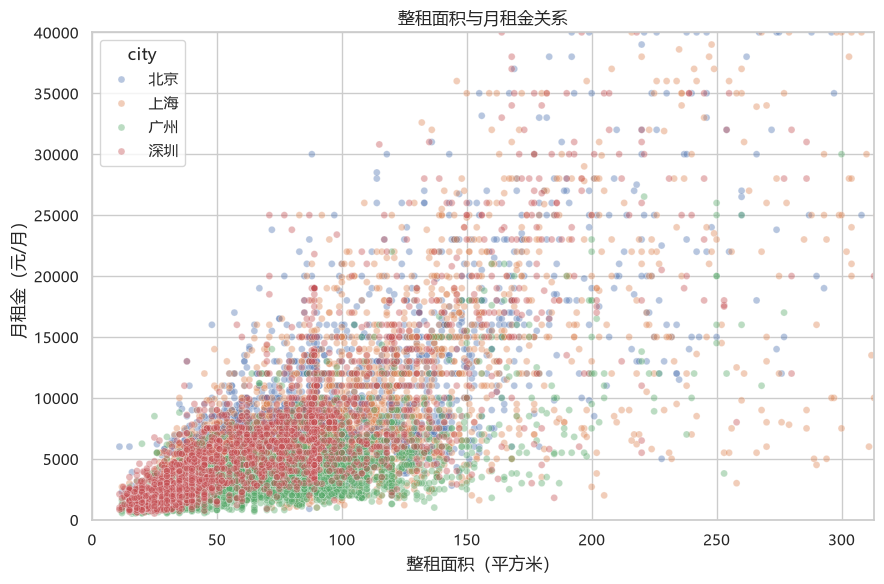

In [11]:
# 绘制整租面积与月租金散点图
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=relationship_df,
    x="rent_area_num",
    y="rent_price_num",
    hue="city",
    alpha=0.4,
    s=25
)

plt.xlim(0, area_display_limit)
plt.ylim(0, rent_display_limit)

plt.title("整租面积与月租金关系")
plt.xlabel("整租面积（平方米）")
plt.ylabel("月租金（元/月）")

plt.tight_layout()
plt.show()

In [12]:
# 计算整租面积与月租金的相关系数
area_rent_corr = relationship_df[
    "rent_area_num"
].corr(
    relationship_df["rent_price_num"]
)

print(
    "整租面积与月租金的相关系数：",
    round(area_rent_corr, 3)
)
# 相关系数是一个介于 -1 和 1 之间的数字：
# 大于0：正相关，面积越大时，租金通常也越高。
# 小于0：负相关，面积越大时，租金通常越低。
# 接近0：没有明显的线性关系，但不代表二者完全没有其他形式的关系。
# 越接近 1 或 -1，线性关系通常越明显。

整租面积与月租金的相关系数： 0.707


In [13]:
# 分城市统计样本量和面积租金相关系数
city_corr_list = []

for city_name, city_data in relationship_df.groupby(
    "city"
):
    city_count = len(city_data)

    city_corr = city_data[
        "rent_area_num"
    ].corr(
        city_data["rent_price_num"]
    )

    city_corr_list.append({
        "city": city_name,
        "整租房源数量": city_count,
        "面积与月租金相关系数": round(
            city_corr,
            3
        )
    })

city_area_rent_corr = pd.DataFrame(
    city_corr_list
)

city_area_rent_corr = city_area_rent_corr.sort_values(
    by="面积与月租金相关系数",
    ascending=False
).reset_index(drop=True)

city_area_rent_corr

,city,整租房源数量,面积与月租金相关系数
0,深圳,2670,0.743
1,北京,2991,0.730
2,上海,2991,0.703
3,广州,2874,0.655


## 四、分析不同卧室数量的月租金差异

In [14]:
# 统计各卧室数量的有效整租样本量
bedroom_sample_count = relationship_df.groupby(
    "bedroom_num"
)["rent_price_num"].count()

bedroom_sample_count = bedroom_sample_count.reset_index()

bedroom_sample_count.columns = [
    "卧室数量",
    "整租房源数量"
]

bedroom_sample_count = bedroom_sample_count.sort_values(
    by="卧室数量",
    ascending=True
).reset_index(drop=True)

print(
    "关系分析房源数量：",
    len(relationship_df)
)

print(
    "卧室数量缺失记录：",
    relationship_df["bedroom_num"].isna().sum()
)

print(
    "卧室数量有效记录：",
    bedroom_sample_count["整租房源数量"].sum()
)

bedroom_sample_count

关系分析房源数量： 11526
卧室数量缺失记录： 3
卧室数量有效记录： 11523


,卧室数量,整租房源数量
0,1.0,3540
1,2.0,4004
2,3.0,2904
3,4.0,781
4,5.0,221
5,6.0,48
6,7.0,12
7,8.0,6
8,9.0,6
9,10.0,1


In [15]:
# 建立1至5室的正式比较副本
bedroom_comparison_df = relationship_df[
    relationship_df["bedroom_num"].between(
        1,
        5
    )
].copy()


In [16]:
# 按卧室数量计算样本量
bedroom_rent_count = bedroom_comparison_df.groupby(
    "bedroom_num"
)["rent_price_num"].count()

In [17]:
# 按卧室数量计算月租金中位数
bedroom_rent_median = bedroom_comparison_df.groupby(
    "bedroom_num"
)["rent_price_num"].median()

In [18]:
# 平均数只作为补充
bedroom_rent_mean = bedroom_comparison_df.groupby(
    "bedroom_num"
)["rent_price_num"].mean().round(2)

In [19]:
# 组合统计结果
bedroom_rent = pd.DataFrame({
    "整租房源数量": bedroom_rent_count,
    "月租金中位数": bedroom_rent_median,
    "平均月租金": bedroom_rent_mean
})

bedroom_rent = bedroom_rent.reset_index()

bedroom_rent.columns = [
    "卧室数量",
    "整租房源数量",
    "月租金中位数",
    "平均月租金"
]

bedroom_rent

,卧室数量,整租房源数量,月租金中位数,平均月租金
0,1.0,3540,3200.0,3973.68
1,2.0,4004,5200.0,6181.40
2,3.0,2904,6200.0,8619.06
3,4.0,781,12000.0,16419.78
4,5.0,221,17000.0,23657.96


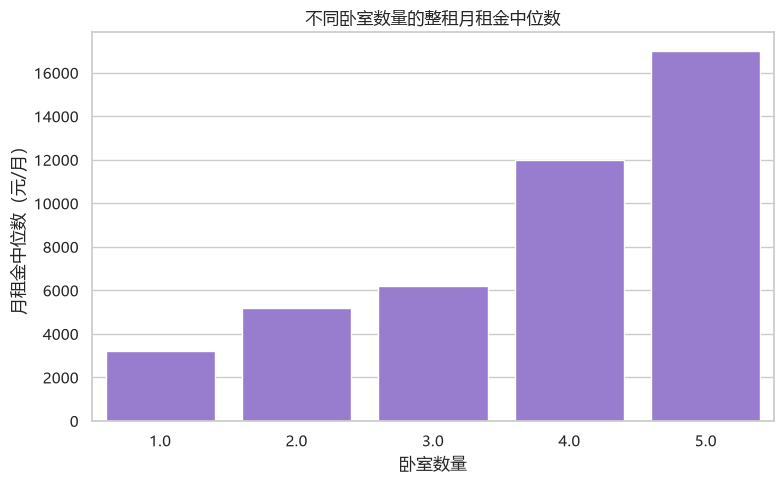

In [20]:
# 绘制不同卧室数量的月租金中位数
plt.figure(figsize=(8, 5))

sns.barplot(
    data=bedroom_rent,
    x="卧室数量",
    y="月租金中位数",
    color="mediumpurple"
)

plt.title("不同卧室数量的整租月租金中位数")
plt.xlabel("卧室数量")
plt.ylabel("月租金中位数（元/月）")

plt.tight_layout()
plt.show()

## 五、统一检查分析结果

In [21]:
# 统一检查第7天使用的数据和主要结果
print("清洗数据规模：", df.shape)
print("整租房源数量：", len(entire_df))
print("关系分析房源数量：", len(relationship_df))
print("关系分析出租类型：", relationship_df["type"].unique())

print(
    "关系分析中的异常标记数量：",
    relationship_df[
        [
            "is_small_entire",
            "is_large_area_conflict",
            "is_low_price_entire"
        ]
    ].sum().sum()
)

print(
    "总体面积租金相关系数：",
    round(area_rent_corr, 3)
)

print(
    "城市相关系数结果数量：",
    len(city_area_rent_corr)
)

print(
    "正式比较的卧室数组别：",
    bedroom_rent["卧室数量"].tolist()
)

print(
    "1至5室房源数量：",
    bedroom_rent["整租房源数量"].sum()
)

清洗数据规模： (11978, 26)
整租房源数量： 11564
关系分析房源数量： 11526
关系分析出租类型： <StringArray>
['整租']
Length: 1, dtype: str
关系分析中的异常标记数量： 0
总体面积租金相关系数： 0.707
城市相关系数结果数量： 4
正式比较的卧室数组别： [1.0, 2.0, 3.0, 4.0, 5.0]
1至5室房源数量： 11450


## 数据分析总结

### 数据基本情况

- 清洗数据共有11,978条记录和26个字段，其中整租房源11,564条。
- 第7天只分析整租，没有把合租混入面积、卧室数量和月租金关系分析。
- 既有异常标记中，小面积整租有11条、超大面积冲突有1条、低价整租有27条；至少带有一种标记的整租房源共有38条。
- 仅为第7天建立关系分析副本，排除上述38条已标记记录，最终使用11,526条整租房源；df、entire_df和清洗CSV均未修改。
- 关系分析副本中有3条卧室数量缺失记录，没有把缺失值填充为0。
- 1至5室共有11,450条房源，作为不同卧室数量月租金的正式比较范围。
- 6室有48条，7室至10室每组只有1至12条，样本量明显较少，因此不用于主要租金差异结论。

### 主要分析结果

- 散点图显示，整租面积增加时，月租金整体呈上升趋势。
- 整租面积与月租金的总体相关系数约为0.707，说明两者存在比较明显的正线性关系。
- 深圳、北京、上海和广州的相关系数分别约为0.743、0.730、0.703和0.655，四个城市内部都存在正相关。
- 相关关系不能证明因果关系，月租金还可能受到城市、行政区、装修和交通等因素影响。
- 1室至5室的月租金中位数分别为3,200元、5,200元、6,200元、12,000元和17,000元。
- 在正式比较范围内，卧室数量越多，典型月租金总体越高，其中3室到4室的月租金中位数增长较明显。
- 各卧室数组别的平均月租金均高于中位数，说明少数高价房源会拉高平均值，因此典型租金继续主要参考中位数。
- 散点图根据实际99%分位数限制显示范围，仅改善图形可读性，没有删除关系分析副本中的其他记录。